# Optimising a Neural Network Classifier

In this notebook, we demonstrate how to **tune hyperparameters** in a neural network model to improve performance.

We will focus on:
- `hidden_layer_sizes`
- `alpha` (regularization)
- `learning_rate_init`

We'll also visualize how these parameters affect accuracy, and look for signs of overfitting or underfitting.

## Step 1: Load Breast Cancer Data

Load with Normalisation 

In [8]:
# from sklearn.datasets import load_breast_cancer
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# import pandas as pd

# # Load dataset
# data = load_breast_cancer()
# X = data.data
# y = data.target

# # Split dataset
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=31
# )

# # Normalize (Standardize) features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

Load without Normalisation 
To see the effects of different network sizes and other hyperparameters we use the non-normlaised dataset. For teh easier task of calssifying using normalised data most values for hyperparameters result in a very good accuracy. 

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=31
)


## Step 2: Define a Function to Train and Evaluate

This function will:
- Train the MLP model
- Return training and test accuracy

In [10]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np

def train_and_evaluate(hidden_layer_sizes=(200, 400, 400, 200), alpha=0.0001, lr=0.001):
    model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,
                           alpha=alpha,
                           learning_rate_init=lr,
                           max_iter=2000,
                           random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    return train_acc, test_acc

## Step 3: Explore Effect of `hidden_layer_sizes`

The number of neurons and layers controls the model’s capacity.

- Too small: underfitting
- Too large: overfitting

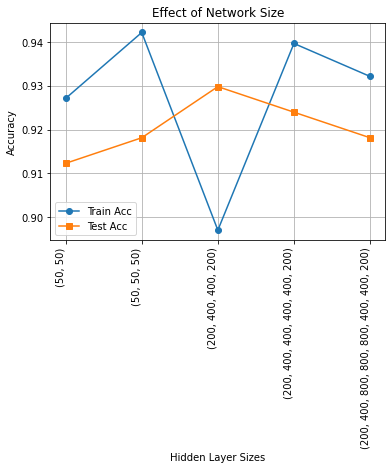

In [11]:
import matplotlib.pyplot as plt

values = [ (50,50), (50, 50, 50), (200, 400, 400, 200), (200, 400, 400, 400, 400, 200), (200, 400, 800, 800, 800, 400, 400, 200)]
labels = [0, 1, 2, 3, 4]
train_scores, test_scores = [], []

for s in values:
    tr, te = train_and_evaluate(hidden_layer_sizes=s)
    train_scores.append(tr)
    test_scores.append(te)

labels = [str(s) for s in values]

plt.plot(labels, train_scores, marker='o', label='Train Acc')
plt.plot(labels, test_scores, marker='s', label='Test Acc')
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Accuracy')
plt.title('Effect of Network Size')
plt.legend()
plt.grid(True)
plt.xticks(rotation=90, ha='right')
plt.show()

## Step 4: Explore Effect of `alpha` (L2 Regularization)

`alpha` prevents overfitting by penalising large weights.

- Low `alpha`: can overfit
- High `alpha`: can underfit

$$
\text{Loss} = \text{Original Loss} + \frac{\alpha}{2} \sum_{i} w_i^2
$$


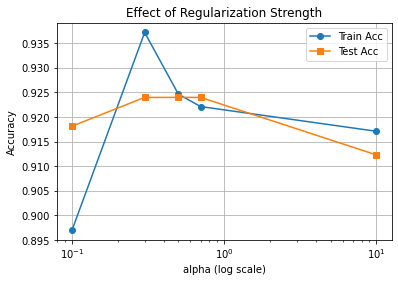

In [12]:
alphas =  [1e-1, 3e-1, 5e-1, 7e-1, 1e1]
train_scores, test_scores = [], []

for a in alphas:
    tr, te = train_and_evaluate(alpha=a)
    train_scores.append(tr)
    test_scores.append(te)

plt.semilogx(alphas, train_scores, marker='o', label='Train Acc')
plt.semilogx(alphas, test_scores, marker='s', label='Test Acc')
plt.xlabel('alpha (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of Regularization Strength')
plt.legend()
plt.grid(True)
plt.show()

## Step 5: Explore Effect of `learning_rate_init`

This controls how fast the model updates its weights.

- Too small: slow convergence
- Too large: may never converge

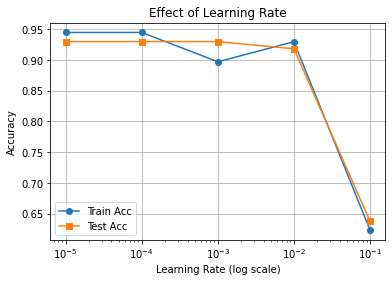

In [13]:
lrs = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
train_scores, test_scores = [], []

for lr in lrs:
    tr, te = train_and_evaluate(lr=lr)
    train_scores.append(tr)
    test_scores.append(te)

plt.plot(lrs, train_scores, marker='o', label='Train Acc')
plt.plot(lrs, test_scores, marker='s', label='Test Acc')
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of Learning Rate')
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

- Neural networks are sensitive to hyperparameters
- Use visualisation to find sweet spot
- Avoid overfitting by tuning `alpha` and `hidden_layer_sizes`
- Don’t pick hyperparameters blindly – use grid search or cross-validation

---------------------------------

## Changing the Classification Threshold

Most classifiers like neural networks output probabilities between 0 and 1.
By default, the threshold for classification is 0.5. This means:

- If predicted probability ≥ 0.5 → classify as **positive**
- Else → classify as **negative**

### Changing the Threshold:
- **Lower threshold** → more positives predicted → higher **recall**, more **false positives**
- **Higher threshold** → fewer positives predicted → higher **precision**, more **false negatives**

Choosing the right threshold depends on your application's goals.

We'll now visualize how the confusion matrix changes for **two different thresholds**.

/home/271/mg0066/.local/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


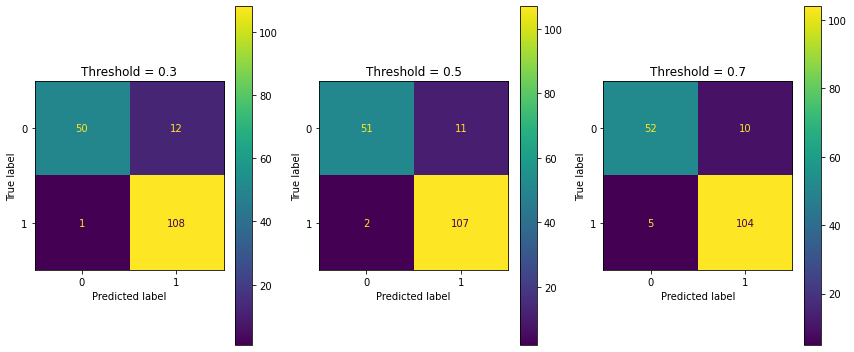

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

thresholds = [0.3, 0.5, 0.7]         # List of two thresholds to compare

# Retrain model
manual_model = MLPClassifier()
manual_model.fit(X_train, y_train)

# Predict probabilities
y_proba = manual_model.predict_proba(X_test)[:, 1]

# Plot side-by-side confusion matrices
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
for i, thresh in enumerate(thresholds):
    y_pred = (y_proba >= thresh).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axs[i])
    axs[i].set_title(f"Threshold = {thresh}")
plt.tight_layout()
plt.show()